In [1]:
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot
import imblearn
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn import datasets
from sklearn.preprocessing import LabelBinarizer

In [2]:
df = pd.read_excel("/content/Clearing missing value  with v225 for coding result in Dissertation.xlsx")
df

,V001,V002,V012,V013,V024,V025,V106,V113,V130,V157,...,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,filter_$
0,548,158,32,4,7,2,3,12,1,0,...,1,1,1,1,2,1,0,1,4,1
1,182,19,24,2,3,1,2,12,1,0,...,1,1,0,4,3,1,2,1,4,1
2,10,46,30,4,1,1,3,21,1,0,...,1,1,1,4,4,2,2,1,4,1
3,74,44,28,3,2,1,2,11,1,0,...,1,1,1,3,1,1,1,1,4,1
4,217,79,34,4,3,1,2,21,1,0,...,2,2,1,4,3,2,2,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,80,44,27,3,2,1,2,11,1,0,...,1,1,1,3,3,1,2,1,1,1
347,332,8,21,2,4,2,2,71,1,0,...,1,1,0,4,3,0,0,1,1,1
348,256,1,20,2,3,2,3,21,1,0,...,1,0,1,0,3,2,0,1,1,1
349,397,36,27,3,5,2,1,21,1,0,...,1,1,1,2,4,2,0,1,1,1


In [4]:
df.drop(columns=['V001', 'V002', 'V012', 'V113', 'V130', 'V157', 'V158',
                 'V159', 'V190', 'V201', 'V212', 'V218', 'V221', 'V364','V437','V438' ,'V445','V447', 'V501',
                 'V502', 'V701', 'V705', 'V730'], inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   V013                   351 non-null    int64  
 1   V024                   351 non-null    int64  
 2   V025                   351 non-null    int64  
 3   V106                   351 non-null    int64  
 4   V225                   351 non-null    int64  
 5   V404                   351 non-null    int64  
 6   V714                   351 non-null    int64  
 7   BMI_fixed              351 non-null    float64
 8   Media_acccess          351 non-null    int64  
 9   husband_education      351 non-null    int64  
 10  contraceptive_use      351 non-null    int64  
 11  Number_of_children     351 non-null    int64  
 12  Living_children        351 non-null    int64  
 13  Age_of_husband         351 non-null    int64  
 14  profession_of_husband  351 non-null    int64  
 15  Birth_

In [6]:
df.drop(columns=['BMI_fixed'], inplace=True)

In [7]:
# Robust Scaling (FT4)
from sklearn.preprocessing import RobustScaler  # import robust scaler
FT4 = RobustScaler()  # create the robust scaler
FT4_data = FT4.fit_transform(df)  # scale data using median and spread
FT4_df = pd.DataFrame(FT4_data, columns=df.columns)  # convert scaled data into a DataFrame
print(FT4_df.head())  # show the first few robust scaled rows

   V013  V024  V025  V106  V225  V404  V714  Media_acccess  husband_education  \
0   0.5   0.6   0.0   1.0   0.0   0.0   0.0           -1.0                0.0   
1  -0.5  -0.2  -1.0   0.0   0.0   0.0   0.0           -1.0               -1.0   
2   0.5  -0.6  -1.0   1.0   0.0   0.0   0.0            0.0                2.0   
3   0.0  -0.4  -1.0   0.0   0.0   0.0   0.0           -1.0               -1.0   
4   0.5  -0.2  -1.0   0.0   2.0   0.0   0.0           -1.0                1.0   

   contraceptive_use  Number_of_children  Living_children  Age_of_husband  \
0                0.0                 0.0              0.0             0.0   
1                0.0                 0.0              0.0            -1.0   
2                0.0                 0.0              0.0             0.0   
3                0.0                 0.0              0.0             0.0   
4                0.0                 1.0              1.0             0.0   

   profession_of_husband  Birth_Interval  Drinking

In [8]:
df.info()  # check the data types and missing values again

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   V013                   351 non-null    int64
 1   V024                   351 non-null    int64
 2   V025                   351 non-null    int64
 3   V106                   351 non-null    int64
 4   V225                   351 non-null    int64
 5   V404                   351 non-null    int64
 6   V714                   351 non-null    int64
 7   Media_acccess          351 non-null    int64
 8   husband_education      351 non-null    int64
 9   contraceptive_use      351 non-null    int64
 10  Number_of_children     351 non-null    int64
 11  Living_children        351 non-null    int64
 12  Age_of_husband         351 non-null    int64
 13  profession_of_husband  351 non-null    int64
 14  Birth_Interval         351 non-null    int64
 15  Drinking_water         351 non-null    i

In [9]:
# FT4_df.head()  # this would preview the robust scaled data
y = FT4_df.BMI  # use bmi1 as the target variable
x = FT4_df.drop('BMI', axis=1)  # use the other columns as features

In [10]:
y  # display the target column

,BMI
0,2.0
1,2.0
2,2.0
3,2.0
4,2.0
...,...
346,-1.0
347,-1.0
348,-1.0
349,-1.0


In [11]:
x  # display the feature columns

,V013,V024,V025,V106,V225,V404,V714,Media_acccess,husband_education,contraceptive_use,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,filter_$
0,0.5,0.6,0.0,1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,-1.0,-0.5,0.0,0.0
1,-0.5,-0.2,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,-1.0,0.5,0.4,-1.0,0.5,0.0,0.0
2,0.5,-0.6,-1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.5,0.8,0.0,0.5,0.0,0.0
3,0.0,-0.4,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,-0.4,-1.0,0.0,0.0,0.0
4,0.5,-0.2,-1.0,0.0,2.0,0.0,0.0,-1.0,1.0,0.0,1.0,1.0,0.0,0.5,0.4,0.0,0.5,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,0.0,-0.4,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.4,-1.0,0.5,0.0,0.0
347,-0.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.5,0.4,-2.0,-0.5,0.0,0.0
348,-0.5,-0.2,0.0,1.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,-1.0,0.0,-1.5,0.4,0.0,-0.5,0.0,0.0
349,0.0,0.2,0.0,-1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.5,0.8,0.0,-0.5,0.0,0.0


In [12]:
y = LabelEncoder().fit_transform(y)  # change target labels into numbers
oversample = SMOTE()  # create SMOTE to balance classes
x, y = oversample.fit_resample(x, y)  # make class counts more balanced
counter = Counter(y)  # count samples in each class
for k, v in counter.items():  # loop through each class count
  per = v / len(y) * 100  # calculate class percentage
  print('class=%d, count=%d, percentage=%.3f%%' % (k, v, per))  # print class distribution

class=3, count=169, percentage=25.000%
class=2, count=169, percentage=25.000%
class=1, count=169, percentage=25.000%
class=0, count=169, percentage=25.000%


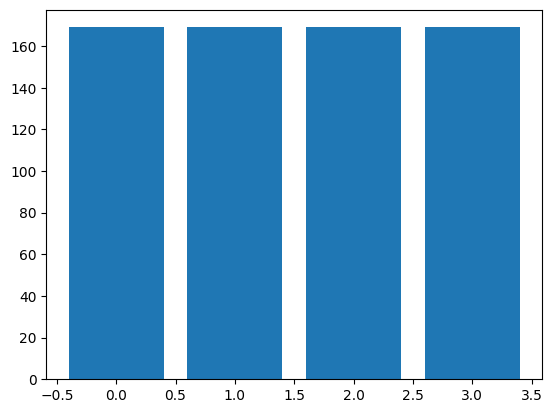

In [13]:
pyplot.bar(counter.keys(), counter.values())  # draw a bar chart for class counts
pyplot.show()  # show the chart

In [14]:
from sklearn.model_selection import train_test_split  # import the train-test split tool
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)  # split data into training and testing sets
x_train.head()  # preview the training features
x_train.shape  # check the training data shape

(473, 19)

In [15]:
x_test.head()  # preview the testing features
x_test.shape  # check the testing data shape

(203, 19)

In [16]:
# logistic regression
from sklearn.linear_model import LogisticRegression  # import logistic regression
Lr = LogisticRegression()  # create the model
Lr.fit(x_train, y_train)  # train the model on the training data

# Generate predictions for both test and training data
predictions = Lr.predict(x_test)  # predict labels for the test set
train_predictions = Lr.predict(x_train)  # predict labels for the training set

from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools

# Train performance
print("=== Training Performance ===")  # print training results heading
print(classification_report(y_train, train_predictions, digits=4))  # show training metrics
print(confusion_matrix(y_train, train_predictions))  # show training confusion matrix
# test performance
print("=== Test Performance ===")  # print test results heading
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = Lr.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities for ROC work

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # measure agreement between true and predicted labels

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(Lr, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

=== Training Performance ===
              precision    recall  f1-score   support

           0     0.6207    0.7826    0.6923       115
           1     0.4545    0.2991    0.3608       117
           2     0.4186    0.3158    0.3600       114
           3     0.5939    0.7717    0.6712       127

    accuracy                         0.5476       473
   macro avg     0.5219    0.5423    0.5211       473
weighted avg     0.5237    0.5476    0.5246       473

[[90  8 11  6]
 [30 35 22 30]
 [25 22 36 31]
 [ 0 12 17 98]]
=== Test Performance ===
              precision    recall  f1-score   support

           0     0.6167    0.6852    0.6491        54
           1     0.4815    0.2500    0.3291        52
           2     0.3947    0.2727    0.3226        55
           3     0.4487    0.8333    0.5833        42

    accuracy                         0.4926       203
   macro avg     0.4854    0.5103    0.4710       203
weighted avg     0.4872    0.4926    0.4651       203

[[37  2  7  8]


In [17]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier  # import decision tree model
dtree = DecisionTreeClassifier()  # create the model
dtree.fit(x_train, y_train)  # train the model
predictions = dtree.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = dtree.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(dtree, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.7800    0.7222    0.7500        54
           1     0.4118    0.4038    0.4078        52
           2     0.5111    0.4182    0.4600        55
           3     0.5965    0.8095    0.6869        42

    accuracy                         0.5764       203
   macro avg     0.5748    0.5884    0.5762       203
weighted avg     0.5749    0.5764    0.5707       203

[[39  5  3  7]
 [ 4 21 17 10]
 [ 5 21 23  6]
 [ 2  4  2 34]]
Cross Validation Scores are [0.48529412 0.69117647 0.76470588 0.66176471 0.66176471 0.61764706
 0.65671642 0.68656716 0.71641791 0.67164179 0.60294118 0.69117647
 0.67647059 0.73529412 0.70588235 0.69117647 0.6119403  0.56716418
 0.67164179 0.70149254 0.66176471 0.60294118 0.72058824 0.67647059
 0.61764706 0.70588235 0.71641791 0.62686567 0.70149254 0.65671642]
Average Cross Validation score :0.665188762071993


In [18]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier  # import random forest model
rfc = RandomForestClassifier(n_estimators=100)  # create the model with 100 trees
rfc.fit(x_train, y_train)  # train the model
predictions = rfc.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = rfc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(rfc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.9592    0.8704    0.9126        54
           1     0.4909    0.5192    0.5047        52
           2     0.5185    0.5091    0.5138        55
           3     0.8444    0.9048    0.8736        42

    accuracy                         0.6897       203
   macro avg     0.7033    0.7009    0.7012       203
weighted avg     0.6961    0.6897    0.6920       203

[[47  4  1  2]
 [ 1 27 21  3]
 [ 1 24 28  2]
 [ 0  0  4 38]]
Cross Validation Scores are [0.70588235 0.77941176 0.79411765 0.70588235 0.72058824 0.67647059
 0.76119403 0.74626866 0.7761194  0.71641791 0.69117647 0.72058824
 0.72058824 0.82352941 0.76470588 0.77941176 0.8358209  0.64179104
 0.76119403 0.68656716 0.72058824 0.70588235 0.80882353 0.82352941
 0.75       0.77941176 0.79104478 0.70149254 0.76119403 0.67164179]
Average Cross Validation score :0.7440444834650278


In [19]:
# K- nearest neighbor
from sklearn.neighbors import KNeighborsClassifier  # import KNN model
KN = KNeighborsClassifier()  # create the model
KN.fit(x_train, y_train)  # train the model
predictions = KN.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = KN.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(KN, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.7162    0.9815    0.8281        54
           1     0.5161    0.3077    0.3855        52
           2     0.6129    0.3455    0.4419        55
           3     0.6119    0.9762    0.7523        42

    accuracy                         0.6355       203
   macro avg     0.6143    0.6527    0.6020       203
weighted avg     0.6154    0.6355    0.5944       203

[[53  0  0  1]
 [13 16 11 12]
 [ 8 15 19 13]
 [ 0  0  1 41]]
Cross Validation Scores are [0.58823529 0.70588235 0.69117647 0.61764706 0.73529412 0.60294118
 0.71641791 0.70149254 0.65671642 0.68656716 0.64705882 0.70588235
 0.64705882 0.75       0.70588235 0.66176471 0.65671642 0.58208955
 0.73134328 0.65671642 0.64705882 0.70588235 0.70588235 0.66176471
 0.64705882 0.66176471 0.71641791 0.58208955 0.74626866 0.64179104]
Average Cross Validation score :0.6720954053263096


In [20]:
# GaussianNB
from sklearn.naive_bayes import GaussianNB  # import Gaussian Naive Bayes model
NB = GaussianNB()  # create the model
NB.fit(x_train, y_train)  # train the model
predictions = NB.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = NB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(NB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.6757    0.4630    0.5495        54
           1     0.3846    0.0962    0.1538        52
           2     0.0000    0.0000    0.0000        55
           3     0.2680    0.9762    0.4205        42

    accuracy                         0.3498       203
   macro avg     0.3321    0.3838    0.2810       203
weighted avg     0.3337    0.3498    0.2726       203

[[25  3  0 26]
 [ 9  5  0 38]
 [ 3  4  0 48]
 [ 0  1  0 41]]
Cross Validation Scores are [0.29411765 0.33823529 0.39705882 0.33823529 0.39705882 0.41176471
 0.37313433 0.3880597  0.41791045 0.40298507 0.33823529 0.36764706
 0.42647059 0.38235294 0.36764706 0.41176471 0.34328358 0.41791045
 0.3880597  0.35820896 0.36764706 0.36764706 0.39705882 0.41176471
 0.32352941 0.39705882 0.40298507 0.34328358 0.35820896 0.3880597 ]
Average Cross Validation score :0.3772461223295288


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
# support vector machine
from sklearn.svm import LinearSVC  # import linear SVM model
classifier = LinearSVC()  # create the model
classifier.fit(x_train, y_train)  # train the model
y_predict = classifier.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_predict, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_predict))  # show test confusion matrix
y_score = classifier.fit(x_train, y_train).decision_function(x_test)  # get decision scores

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, y_predict)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(classifier, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.5735    0.7222    0.6393        54
           1     0.5217    0.2308    0.3200        52
           2     0.4138    0.2182    0.2857        55
           3     0.4096    0.8095    0.5440        42

    accuracy                         0.4778       203
   macro avg     0.4797    0.4952    0.4473       203
weighted avg     0.4831    0.4778    0.4420       203

[[39  1  4 10]
 [17 12  8 15]
 [12  7 12 24]
 [ 0  3  5 34]]
Cross Validation Scores are [0.48529412 0.51470588 0.52941176 0.47058824 0.41176471 0.47058824
 0.52238806 0.47761194 0.56716418 0.46268657 0.48529412 0.51470588
 0.5        0.47058824 0.51470588 0.51470588 0.46268657 0.47761194
 0.49253731 0.46268657 0.42647059 0.48529412 0.55882353 0.47058824
 0.47058824 0.52941176 0.53731343 0.47761194 0.41791045 0.46268657]
Average Cross Validation score :0.48814749780509215


In [22]:
# AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier  # import AdaBoost model
abc = AdaBoostClassifier(n_estimators=50, learning_rate=1)  # create the model
model = abc.fit(x_train, y_train)  # train the model
y_pred = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_pred, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_pred))  # show test confusion matrix
y_score = abc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(abc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.8718    0.6296    0.7312        54
           1     0.5079    0.6154    0.5565        52
           2     0.3243    0.2182    0.2609        55
           3     0.4531    0.6905    0.5472        42

    accuracy                         0.5271       203
   macro avg     0.5393    0.5384    0.5239       203
weighted avg     0.5436    0.5271    0.5209       203

[[34  3  4 13]
 [ 4 32 11  5]
 [ 1 25 12 17]
 [ 0  3 10 29]]
Cross Validation Scores are [0.47058824 0.55882353 0.66176471 0.52941176 0.52941176 0.5
 0.58208955 0.58208955 0.59701493 0.56716418 0.51470588 0.45588235
 0.55882353 0.57352941 0.61764706 0.64705882 0.56716418 0.55223881
 0.62686567 0.64179104 0.60294118 0.60294118 0.57352941 0.52941176
 0.51470588 0.63235294 0.58208955 0.52238806 0.50746269 0.52238806]
Average Cross Validation score :0.564142522680714


In [23]:
# GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier  # import gradient boosting model
GB = GradientBoostingClassifier()  # create the model
model = GB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = GB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(GB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.9375    0.8333    0.8824        54
           1     0.5263    0.5769    0.5505        52
           2     0.5000    0.4545    0.4762        55
           3     0.7500    0.8571    0.8000        42

    accuracy                         0.6700       203
   macro avg     0.6785    0.6805    0.6773       203
weighted avg     0.6748    0.6700    0.6703       203

[[45  3  2  4]
 [ 2 30 18  2]
 [ 1 23 25  6]
 [ 0  1  5 36]]
Cross Validation Scores are [0.70588235 0.76470588 0.79411765 0.70588235 0.64705882 0.69117647
 0.76119403 0.68656716 0.86567164 0.7761194  0.66176471 0.75
 0.73529412 0.72058824 0.70588235 0.76470588 0.76119403 0.70149254
 0.76119403 0.71641791 0.70588235 0.70588235 0.73529412 0.75
 0.72058824 0.76470588 0.73134328 0.67164179 0.76119403 0.68656716]
Average Cross Validation score :0.7303336259877085


In [24]:
# XGBoost
from numpy import loadtxt  # import loadtxt from NumPy
from xgboost import XGBClassifier  # import XGBoost model
XGB = XGBClassifier()  # create the model
model = XGB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = XGB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(XGB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.9216    0.8704    0.8952        54
           1     0.5439    0.5962    0.5688        52
           2     0.5510    0.4909    0.5192        55
           3     0.7826    0.8571    0.8182        42

    accuracy                         0.6946       203
   macro avg     0.6998    0.7036    0.7004       203
weighted avg     0.6957    0.6946    0.6938       203

[[47  3  1  3]
 [ 3 31 15  3]
 [ 1 23 27  4]
 [ 0  0  6 36]]
Cross Validation Scores are [0.67647059 0.73529412 0.76470588 0.75       0.67647059 0.66176471
 0.76119403 0.70149254 0.76119403 0.70149254 0.69117647 0.79411765
 0.72058824 0.76470588 0.76470588 0.72058824 0.70149254 0.67164179
 0.71641791 0.70149254 0.72058824 0.73529412 0.77941176 0.75
 0.67647059 0.79411765 0.67164179 0.70149254 0.68656716 0.65671642]
Average Cross Validation score :0.7203102136376939


In [25]:
# Bagging
from sklearn.ensemble import BaggingClassifier
BC=BaggingClassifier()
model=BC.fit(x_train, y_train)
predictions = model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=4))
print(confusion_matrix(y_test,predictions))
y_score = BC.fit(x_train, y_train).predict_proba(x_test)

from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_test,predictions)

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import  cross_val_score,KFold
kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats=3, random_state=1)
scores = cross_val_score(BC, x, y, cv = kf)
print("Cross Validation Scores are {}".format(scores))
print("Average Cross Validation score :{}".format(scores.mean()))

              precision    recall  f1-score   support

           0     0.9574    0.8333    0.8911        54
           1     0.5217    0.6923    0.5950        52
           2     0.6098    0.4545    0.5208        55
           3     0.8043    0.8810    0.8409        42

    accuracy                         0.7044       203
   macro avg     0.7233    0.7153    0.7120       203
weighted avg     0.7200    0.7044    0.7046       203

[[45  5  0  4]
 [ 2 36 12  2]
 [ 0 27 25  3]
 [ 0  1  4 37]]
Cross Validation Scores are [0.64705882 0.70588235 0.75       0.61764706 0.63235294 0.63235294
 0.82089552 0.73134328 0.7761194  0.70149254 0.64705882 0.70588235
 0.67647059 0.77941176 0.79411765 0.75       0.76119403 0.64179104
 0.73134328 0.73134328 0.77941176 0.73529412 0.72058824 0.79411765
 0.63235294 0.82352941 0.74626866 0.70149254 0.68656716 0.68656716]
Average Cross Validation score :0.717998244073749
